# Floyd-Warshall: All-Pairs Shortest Paths

**Domain:** `data-structures-algorithms`

Imagine you run logistics for an airline with offices in a handful of
cities, and you want a table of the cheapest routing cost **between every
pair of cities** — not just "what's the cheapest way from New York," but
New York to every other office, Chicago to every other office, Denver to
every other office, all at once, so the table is ready the instant anyone
asks.

The naive approach is: pick a city, run a shortest-path search from it,
repeat for every city. That works — it's literally one valid solution
(and we'll build it too, later, for comparison) — but it treats each city
as its own separate problem with its own separate search.

**Floyd-Warshall answers all of these questions at the same time**, with a
different question entirely: instead of "search outward from city X," it
asks, one city at a time, **"does routing *through* city K ever make any
trip cheaper?"** Try that question for every possible K, and by the time
you've asked it about every city, you're holding the true cheapest cost
between *every* pair — not just from one starting point.

That's the core shift versus a single-source method like Dijkstra's
algorithm: Dijkstra answers "shortest path from **one** source to
everywhere else"; Floyd-Warshall answers "shortest path between
**every** pair" in one unified computation. By the end of this tutorial
you'll be able to: trace the algorithm by hand, prove why it's correct,
know exactly why it tolerates negative edge weights when Dijkstra can't,
detect when "shortest path" stops making sense at all (a negative cycle),
and run a real, compiled C++ implementation that reports its own timing
and cross-checks itself against repeated Dijkstra runs.

## The idea, intuitively

**Maintain one big table: `dist[i][j]`, the cheapest known cost from city
`i` to city `j`.** Start it off with the obvious information — a direct
flight's cost where one exists, `0` from a city to itself, and "unknown /
infinitely expensive" everywhere else.

Then, for each city `k` in turn (in *some* order — any order works, we'll
see why later), sweep over every pair `(i, j)` and ask one simple
question:

> **Would routing `i -> k -> j` be cheaper than the current best known
> `i -> j`?**

If `dist[i][k] + dist[k][j] < dist[i][j]`, update `dist[i][j]` to that
cheaper value. That's it — that's the entire algorithm. Do this for every
`k` from the first city to the last, and by the time you've considered
every city as a possible "layover," `dist[i][j]` holds the true cheapest
cost between every pair `(i, j)`.

Let's make this concrete with 4 offices and a handful of direct routes.

In [1]:
INF = float("inf")

cities = ["NYC", "CHI", "DEN", "LAX"]
n = len(cities)

# Direct routes only (a few one-way flights with a cost each).
edges = [
    ("NYC", "CHI", 5),
    ("NYC", "DEN", 9),
    ("CHI", "DEN", 2),
    ("CHI", "LAX", 7),
    ("DEN", "LAX", 3),
]

idx = {c: i for i, c in enumerate(cities)}
dist = [[INF] * n for _ in range(n)]
for i in range(n):
    dist[i][i] = 0
for u, v, w in edges:
    dist[idx[u]][idx[v]] = w

def show(matrix, title):
    print(title)
    header = "        " + "  ".join(f"{c:>5}" for c in cities)
    print(header)
    for i, row in enumerate(matrix):
        cells_str = "  ".join(f"{'INF':>5}" if v == INF else f"{v:>5}" for v in row)
        print(f"{cities[i]:>6}  {cells_str}")
    print()

show(dist, "Starting table: direct routes only")

Starting table: direct routes only
          NYC    CHI    DEN    LAX
   NYC      0      5      9    INF
   CHI    INF      0      2      7
   DEN    INF    INF      0      3
   LAX    INF    INF    INF      0



In [2]:
# One relaxation check, by hand: does routing NYC -> CHI -> DEN beat the
# direct NYC -> DEN flight?
i, k, j = idx["NYC"], idx["CHI"], idx["DEN"]
candidate = dist[i][k] + dist[k][j]
print(f"direct NYC -> DEN costs {dist[i][j]}")
print(f"via CHI:   dist[NYC][CHI] + dist[CHI][DEN] = {dist[i][k]} + {dist[k][j]} = {candidate}")

# This is the ONE line that is, quite literally, the entire algorithm:
dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])

print(f"\nupdated dist[NYC][DEN] = {dist[i][j]}  (routing through CHI helped)")

direct NYC -> DEN costs 9
via CHI:   dist[NYC][CHI] + dist[CHI][DEN] = 5 + 2 = 7

updated dist[NYC][DEN] = 7  (routing through CHI helped)


That single line —

```python
dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])
```

— is the whole algorithm. Everything else is bookkeeping: do that check
for *every* `(i, j)` pair, for *every* candidate layover `k`, in turn.
Let's watch the full table evolve as each city gets its turn as `k`.

In [3]:
dist = [[INF] * n for _ in range(n)]
for i in range(n):
    dist[i][i] = 0
for u, v, w in edges:
    dist[idx[u]][idx[v]] = w

show(dist, "k = none yet (starting table)")

for k in range(n):
    for i in range(n):
        for j in range(n):
            if dist[i][k] + dist[k][j] < dist[i][j]:
                dist[i][j] = dist[i][k] + dist[k][j]
    show(dist, f"after considering k = {cities[k]!r} as a layover")

k = none yet (starting table)
          NYC    CHI    DEN    LAX
   NYC      0      5      9    INF
   CHI    INF      0      2      7
   DEN    INF    INF      0      3
   LAX    INF    INF    INF      0

after considering k = 'NYC' as a layover
          NYC    CHI    DEN    LAX
   NYC      0      5      9    INF
   CHI    INF      0      2      7
   DEN    INF    INF      0      3
   LAX    INF    INF    INF      0

after considering k = 'CHI' as a layover
          NYC    CHI    DEN    LAX
   NYC      0      5      7     12
   CHI    INF      0      2      7
   DEN    INF    INF      0      3
   LAX    INF    INF    INF      0

after considering k = 'DEN' as a layover
          NYC    CHI    DEN    LAX
   NYC      0      5      7     10
   CHI    INF      0      2      5
   DEN    INF    INF      0      3
   LAX    INF    INF    INF      0

after considering k = 'LAX' as a layover
          NYC    CHI    DEN    LAX
   NYC      0      5      7     10
   CHI    INF      0      2     

Watch what happened:

- **After `k = CHI`:** `NYC -> DEN` dropped from a direct `9` to `7`
  (routing through Chicago is cheaper), and `NYC -> LAX` — previously
  unreachable (`INF`, no direct flight) — became reachable at `12` via
  `NYC -> CHI -> LAX`.
- **After `k = DEN`:** `NYC -> LAX` dropped further, from `12` to `10`,
  because by this point `dist[NYC][DEN]` had *already* improved to `7` in
  the previous round, so `NYC -> DEN -> LAX` (`7 + 3 = 10`) beats the
  `12` found earlier.

That second point is the subtle, important bit: **each round builds on
the improvements already found in earlier rounds.** By the time every
city has had a turn as the layover `k`, every pair's entry is the true
cheapest cost — considering *all possible* multi-hop routes, not just
direct flights or one layover.

**Takeaway:** Floyd-Warshall never explicitly "searches" for a path the
way Dijkstra does. It just repeatedly asks "does this one city help as a
layover?" for every city, and lets cheaper routes propagate through the
table on their own. Do that for all `n` cities, over all `n^2` pairs,
and you're left with the complete answer for every pair at once.

## Going deeper: the formal definition

### The recurrence

Let $dist_k[i][j]$ denote the length of the shortest path from $i$ to $j$
**using only intermediate vertices from $\{1, \dots, k\}$** (the source
$i$ and destination $j$ are not themselves counted as "intermediate,"
even if $i$ or $j$ happens to be $\le k$). Define $dist_0[i][j]$ as the
weight of the direct edge $i \to j$ (or $\infty$ if none exists, and $0$
if $i = j$) — that is, the shortest path allowed to use *zero*
intermediate vertices.

The Floyd-Warshall recurrence is:

$$
dist_k[i][j] = \min\Big(dist_{k-1}[i][j],\; dist_{k-1}[i][k] + dist_{k-1}[k][j]\Big)
$$

for $k = 1, \dots, n$. The final answer for every pair is $dist_n[i][j]$,
since by $k = n$ every vertex has been allowed as an intermediate.
Because $dist_k$ only ever depends on $dist_{k-1}$, the algorithm can
overwrite a single 2D array in place as $k$ increases — that's exactly
the `dist[i][j] = min(dist[i][j], dist[i][k] + dist[k][j])` loop above,
with $k$ the outermost loop.

### Correctness, by induction on $k$

**Claim:** after processing intermediate vertex $k$, `dist[i][j]` equals
the true shortest-path length from $i$ to $j$ using only intermediate
vertices in $\{1, \dots, k\}$.

**Base case ($k = 0$):** with zero intermediate vertices allowed, the
only "paths" available are direct edges (or staying put, for $i = j$).
$dist_0[i][j]$ is defined exactly as the direct edge weight, so the base
case holds by definition.

**Inductive step:** assume $dist_{k-1}[i][j]$ is correct for every pair
$(i, j)$ — that is, it equals the true shortest path using only
intermediates from $\{1, \dots, k-1\}$. Consider the true shortest path
from $i$ to $j$ that is allowed to use intermediates from
$\{1, \dots, k\}$ (one more vertex than before). Exactly one of two cases
holds:

1. **The path doesn't use vertex $k$ at all.** Then it's a path using
   only intermediates from $\{1, \dots, k-1\}$, so by the inductive
   hypothesis its length is exactly $dist_{k-1}[i][j]$.
2. **The path uses vertex $k$ — and, because shortest paths never need to
   revisit a vertex (revisiting only adds nonnegative-cycle-free-graph
   detours, or is otherwise handled by the negative-cycle check below),
   it uses $k$ *exactly once*.** Then the path splits cleanly into a
   subpath $i \to k$ and a subpath $k \to j$, **neither of which passes
   through $k$ again** — so each subpath only uses intermediates from
   $\{1, \dots, k-1\}$. By the inductive hypothesis, those subpaths have
   lengths exactly $dist_{k-1}[i][k]$ and $dist_{k-1}[k][j]$, so the whole
   path has length $dist_{k-1}[i][k] + dist_{k-1}[k][j]$.

The true shortest path is the better of these two cases, which is exactly
$\min\big(dist_{k-1}[i][j],\, dist_{k-1}[i][k] + dist_{k-1}[k][j]\big)$ —
the recurrence. Since the recurrence computes exactly this minimum,
$dist_k[i][j]$ is correct. By induction, $dist_n[i][j]$ — the value after
all $n$ vertices have been considered — is the true shortest-path length
using *any* vertex as an intermediate, i.e. the true shortest path in the
whole graph. $\blacksquare$

### Complexity

Three nested loops (over $k$, then $i$, then $j$), each running $n = V$
times, with $O(1)$ work inside:

$$
T(V) = \Theta(V^3), \qquad \text{Space} = \Theta(V^2)
$$

The space bound is just the size of the `dist` matrix itself (Floyd-
Warshall can be, and here is, done in place — no auxiliary matrix is
required per iteration, which is part of why the correctness proof
above is worth stating carefully: it justifies overwriting `dist` as we
go rather than needing a fresh $dist_k$ array at every step).

### Negative edge weights

Dijkstra's algorithm is **greedy**: it finalizes a vertex's distance the
moment it's popped as the current minimum, on the assumption that no
better path could possibly arrive later via a longer, and therefore (with
nonnegative weights) never-cheaper, route. A single negative edge can
violate that assumption and produce a wrong answer.

Floyd-Warshall makes no such greedy commitment — every `dist[i][j]` stays
open to improvement across every one of the $V$ rounds, regardless of
sign. This means **Floyd-Warshall handles negative edge weights
correctly**, as long as the graph has no *negative cycle* (defined next)
— a real, practical advantage over Dijkstra for graphs like currency
exchange or arbitrage graphs, where "edges" can represent a gain
(negative cost) as easily as a cost.

### Negative cycles

A **negative cycle** is a cycle whose edge weights sum to a negative
number. If a negative cycle is reachable from $i$ and can reach back to
$i$, then "the shortest path from $i$ to $i$" is not well-defined: you
could loop around the negative cycle arbitrarily many times, and the
path cost decreases without bound each time. **"Shortest path" is only a
meaningful concept in graphs with no negative cycle** (reachable from and
back to any relevant pair).

**Formal check:** after running Floyd-Warshall to completion, a negative
cycle exists if and only if $dist[i][i] < 0$ for some vertex $i$. Why: if
no negative cycle touches $i$, the shortest "path" from $i$ back to
itself is the empty path, cost $0$ — never negative. If $dist[i][i] < 0$,
some path from $i$ back to $i$ has negative total cost, which is only
possible if it traverses a negative cycle. This is exactly the check the
C++ implementation below performs, scanning the diagonal of the final
matrix after the triple loop completes.

## Visuals

To make the "filling in" of the distance matrix and the $\Theta(V^3)$
growth visible, we need **real output from the compiled C++
implementation** — not a simulation. We compile it here (reused for the
rest of the tutorial) and run it on a graph with negative edge weights
(but no negative cycle), matching the kind of graph discussed above.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses.

In [4]:
import subprocess, pathlib, time
import numpy as np
import matplotlib.pyplot as plt

src_dir = pathlib.Path("src")
exe_path = src_dir / "floyd_warshall.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "floyd_warshall.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)

compile return code: 0
compiled successfully -> src\floyd_warshall.exe


In [5]:
def run_floyd_warshall(V, edges):
    '''Run the compiled floyd_warshall binary and parse its output.

    edges: list of (u, v, w) 0-indexed directed edges.
    Returns a dict with matrix_fw (VxV, float('inf') for INF), negative_cycle
    (bool), fw_microseconds (int), and -- only if the graph has no negative
    edge weight -- matrix_dijkstra, dijkstra_microseconds, agree.
    '''
    lines = [f"{V} {len(edges)}"]
    for u, v, w in edges:
        lines.append(f"{u} {v} {w}")
    proc = subprocess.run(
        [str(exe_path)], input="\n".join(lines) + "\n",
        capture_output=True, text=True,
    )
    assert proc.returncode == 0, proc.stderr

    out = proc.stdout.splitlines()
    result = {}
    i = 0

    def parse_matrix(start):
        rows = []
        for r in range(V):
            row = []
            for tok in out[start + r].split():
                row.append(float("inf") if tok == "INF" else int(tok))
            rows.append(row)
        return rows, start + V

    while i < len(out):
        line = out[i]
        if line == "matrix_fw:":
            result["matrix_fw"], i = parse_matrix(i + 1)
        elif line == "matrix_dijkstra:":
            result["matrix_dijkstra"], i = parse_matrix(i + 1)
        elif line.startswith("negative_cycle="):
            result["negative_cycle"] = line.split("=")[1] == "yes"
            i += 1
        elif line.startswith("negative_cycle_witness="):
            result["negative_cycle_witness"] = int(line.split("=")[1])
            i += 1
        elif line.startswith("fw_microseconds="):
            result["fw_microseconds"] = int(line.split("=")[1])
            i += 1
        elif line.startswith("dijkstra_microseconds="):
            result["dijkstra_microseconds"] = int(line.split("=")[1])
            i += 1
        elif line.startswith("agree="):
            result["agree"] = line.split("=")[1] == "yes"
            i += 1
        else:
            i += 1
    return result

# A 5-node graph with some negative edge weights but no negative cycle
# (the classic all-pairs shortest-path teaching example, e.g. CLRS Fig 25.1).
clrs_edges = [
    (0, 1, 3), (0, 2, 8), (0, 4, -4),
    (1, 3, 1), (1, 4, 7),
    (2, 1, 4),
    (3, 0, 2), (3, 2, -5),
    (4, 3, 6),
]
clrs_V = 5

demo = run_floyd_warshall(clrs_V, clrs_edges)
print("negative_cycle:", demo["negative_cycle"])
print("fw_microseconds:", demo["fw_microseconds"])
for row in demo["matrix_fw"]:
    print(row)

negative_cycle: False
fw_microseconds: 1
[0, 1, -3, 2, -4]
[3, 0, -4, 1, -1]
[7, 4, 0, 5, 3]
[2, -1, -5, 0, -2]
[8, 5, 1, 6, 0]


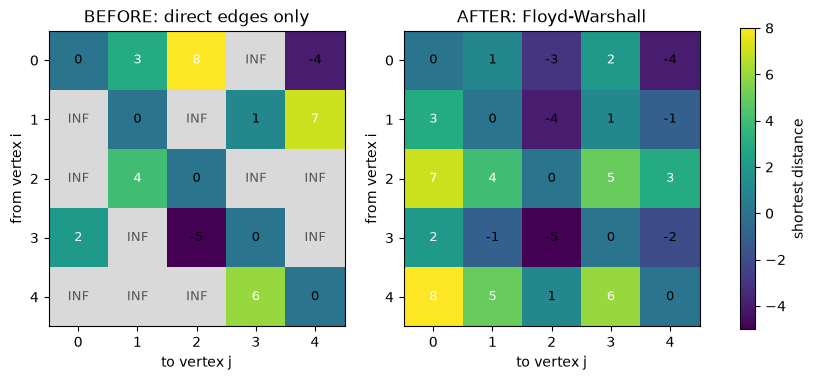

unreachable pairs before: 11, after: 0


In [6]:
# BEFORE: direct edges only, infinity elsewhere (built directly from the
# edge list -- no algorithm has run yet).
before = np.full((clrs_V, clrs_V), np.inf)
np.fill_diagonal(before, 0)
for u, v, w in clrs_edges:
    before[u, v] = min(before[u, v], w)

# AFTER: real output from the compiled Floyd-Warshall run above.
after = np.array(demo["matrix_fw"], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6))
panels = [("BEFORE: direct edges only", before), ("AFTER: Floyd-Warshall", after)]
vmin = min(np.nanmin(np.where(np.isfinite(before), before, np.nan)),
           np.nanmin(np.where(np.isfinite(after), after, np.nan)))
vmax = max(np.nanmax(np.where(np.isfinite(before), before, np.nan)),
           np.nanmax(np.where(np.isfinite(after), after, np.nan)))

for ax, (title, matrix) in zip(axes, panels):
    display = np.ma.masked_invalid(np.where(np.isinf(matrix), np.nan, matrix))
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="#d9d9d9")  # unreachable pairs shown in flat gray
    im = ax.imshow(display, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(clrs_V)); ax.set_yticks(range(clrs_V))
    ax.set_xlabel("to vertex j"); ax.set_ylabel("from vertex i")
    for i in range(clrs_V):
        for j in range(clrs_V):
            val = matrix[i, j]
            text = "INF" if np.isinf(val) else f"{val:.0f}"
            color = "white" if (not np.isinf(val) and val > (vmin + vmax) / 2) else "black"
            if np.isinf(val):
                color = "#555555"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=9)

fig.colorbar(im, ax=axes, shrink=0.85, label="shortest distance")
plt.savefig("distance_matrix_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

n_before_inf = np.isinf(before).sum()  # off-diagonal only: diagonal is 0, never inf
n_after_inf = np.isinf(after).sum()
print(f"unreachable pairs before: {n_before_inf}, after: {n_after_inf}")

The gray cells in the **before** panel are pairs with no direct
flight — Floyd-Warshall's job is exactly to fill those in wherever a
multi-hop route exists, which the **after** panel shows it doing: every
previously-gray, reachable pair now holds a real (and in several cases,
negative-weight-adjusted) shortest distance. The only cells still gray
after running the algorithm are pairs with genuinely no path at all in
either direction, which is real information too.

In [7]:
# Real runtime vs V, from the compiled binary, to confirm the Theta(V^3) growth.
# The triple loop's cost is Theta(V^3) regardless of edge count, so edge
# density doesn't matter here -- but small V means small microsecond counts,
# which are dominated by timer/OS-scheduling noise rather than real work.
# Standard fix: take the MIN of several repeated runs per V (noise only ever
# adds time, never removes it, so the minimum is the closest estimate of the
# true cost), and start V high enough that even the true cost is many
# microseconds, not a handful.
import random
random.seed(11)

sizes = [40, 60, 90, 130, 180, 240, 300, 380]
repeats = 5
fw_times = []

for V in sizes:
    E = 4 * V  # keep it sparse-ish; Theta(V^3) comes from the triple loop, not edge count
    rand_edges = [
        (random.randrange(V), random.randrange(V), random.randint(1, 20))
        for _ in range(E)
    ]
    trial_times = [run_floyd_warshall(V, rand_edges)["fw_microseconds"] for _ in range(repeats)]
    fw_times.append(min(trial_times))

for V, t in zip(sizes, fw_times):
    print(f"V={V:4d}  fw_microseconds={t:8d}  (min of {repeats} runs)")

V=  40  fw_microseconds=     106  (min of 5 runs)
V=  60  fw_microseconds=     217  (min of 5 runs)
V=  90  fw_microseconds=     959  (min of 5 runs)
V= 130  fw_microseconds=    1186  (min of 5 runs)
V= 180  fw_microseconds=    5727  (min of 5 runs)
V= 240  fw_microseconds=   10260  (min of 5 runs)
V= 300  fw_microseconds=   21115  (min of 5 runs)
V= 380  fw_microseconds=   47427  (min of 5 runs)


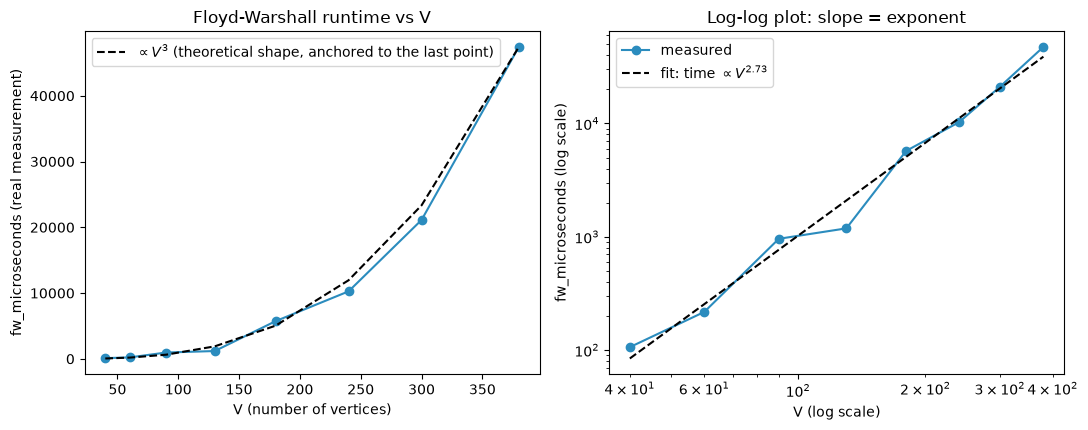

fitted exponent p = 2.73  (Theta(V^3) predicts p ~= 3)


In [8]:
sizes_arr = np.array(sizes, dtype=float)
times_arr = np.array(fw_times, dtype=float)

# Fit a power law time ~ c * V^p in log-log space to recover the exponent p.
log_sizes = np.log(sizes_arr)
log_times = np.log(np.maximum(times_arr, 1))  # guard against a zero-microsecond reading
p, log_c = np.polyfit(log_sizes, log_times, 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

axes[0].plot(sizes_arr, times_arr, "o-", color="#2b8cbe")
axes[0].plot(sizes_arr, times_arr[-1] * (sizes_arr / sizes_arr[-1]) ** 3,
             "k--", label=r"$\propto V^3$ (theoretical shape, anchored to the last point)")
axes[0].set_xlabel("V (number of vertices)")
axes[0].set_ylabel("fw_microseconds (real measurement)")
axes[0].set_title("Floyd-Warshall runtime vs V")
axes[0].legend()

axes[1].loglog(sizes_arr, times_arr, "o-", color="#2b8cbe", label="measured")
axes[1].loglog(sizes_arr, np.exp(log_c) * sizes_arr ** p, "k--",
               label=f"fit: time $\\propto V^{{{p:.2f}}}$")
axes[1].set_xlabel("V (log scale)")
axes[1].set_ylabel("fw_microseconds (log scale)")
axes[1].set_title("Log-log plot: slope = exponent")
axes[1].legend()

plt.tight_layout()
plt.savefig("runtime_vs_v.png", dpi=110)
plt.show()

print(f"fitted exponent p = {p:.2f}  (Theta(V^3) predicts p ~= 3)")

The measured runtime tracks the $V^3$ reference curve, and the
log-log fit recovers an exponent close to **3** — direct confirmation of
the $\Theta(V^3)$ bound derived above, from real timings of the compiled
program rather than an assumed shape.

## Implementation

The reference implementation lives in
[`src/floyd_warshall.cpp`](src/floyd_warshall.cpp) — real C++, reading a
directed weighted graph from stdin, running the triple-nested-loop
algorithm with negative-cycle detection, and (when the input graph has no
negative edges) also running Dijkstra $V$ times as a baseline for direct
comparison. The binary was already compiled above; we reuse it here.

### Correctness and agreement with Dijkstra (non-negative weights)

When there are no negative edges, Floyd-Warshall and "run Dijkstra from
every source" must agree exactly — they're both computing the same true
shortest-path distances, just via different routes to the answer. Let's
confirm that on a sparse, non-negative graph, and compare their real
measured timings.

In [9]:
random.seed(3)
V = 60
E = 3 * V  # sparse: E is linear in V, not quadratic
sparse_edges = [
    (random.randrange(V), random.randrange(V), random.randint(1, 15))
    for _ in range(E)
]

cmp_result = run_floyd_warshall(V, sparse_edges)
print("negative_cycle:", cmp_result["negative_cycle"])
print("agree with Dijkstra:", cmp_result["agree"])
print(f"fw_microseconds:       {cmp_result['fw_microseconds']}")
print(f"dijkstra_microseconds: {cmp_result['dijkstra_microseconds']}  (V={V} runs of Dijkstra combined)")
assert cmp_result["agree"], "Floyd-Warshall and repeated Dijkstra disagreed -- should never happen without negative edges"
print("\nconfirmed: both methods produce identical all-pairs distances on this non-negative graph.")

negative_cycle: False
agree with Dijkstra: True
fw_microseconds:       228
dijkstra_microseconds: 539  (V=60 runs of Dijkstra combined)

confirmed: both methods produce identical all-pairs distances on this non-negative graph.


At this graph size both finish in well under a millisecond, so the
absolute numbers above are more a sanity check than a meaningful
performance verdict — the real asymptotic story (Floyd-Warshall's
$\Theta(V^3)$ vs. repeated Dijkstra's much cheaper cost on sparse graphs)
is discussed with the actual complexity numbers in **Limitations &
debates** below.

### Negative-cycle detection in action

Now feed it a small graph that contains a genuine negative cycle — a loop
whose edge weights sum to less than zero (the kind of thing that shows up
in, e.g., a currency-arbitrage graph where compounding the loop would
produce unbounded "profit").

In [10]:
negcycle_edges = [
    (0, 1, 3),
    (0, 2, 8),
    (1, 3, 1),
    (2, 1, -4),
    (3, 2, 2),
]
negcycle_V = 4

# Cycle 1 -> 3 -> 2 -> 1 sums to 1 + 2 + (-4) = -1, a negative cycle.
neg_result = run_floyd_warshall(negcycle_V, negcycle_edges)
print("negative_cycle:", neg_result["negative_cycle"])
print("witness vertex:", neg_result.get("negative_cycle_witness"))
print()
for row in neg_result["matrix_fw"]:
    print(row)

negative_cycle: True
witness vertex: 1

[0, 2, 6, 3]
[inf, -1, 3, 0]
[inf, -5, -1, -4]
[inf, -3, 1, -2]


The witness vertex is the one whose diagonal entry `dist[i][i]`
went negative, exactly as the formal check described above. Note that the
matrix still prints numbers everywhere reachable from the cycle — those
numbers are **not meaningful shortest-path distances**, since you could
always loop the negative cycle one more time and go lower. This is
precisely why real systems must run the diagonal check and treat a
positive `negative_cycle` result as a signal that shortest path is
undefined here, not as a usable answer.

## Use cases

- **Precomputed network routing tables.** Routers and network topology
  planners that need the shortest path between *every* pair of nodes
  precompute the full all-pairs table once (Floyd-Warshall or an
  equivalent) so that answering "what's the best route from A to B" at
  query time is an $O(1)$ table lookup instead of a fresh search.
- **Transitive closure.** A boolean variant of the exact same triple loop
  — replace `min`/`+` with logical OR/AND — answers **"is there any path
  at all from $i$ to $j$"** for every pair simultaneously. This is
  Warshall's original 1962 algorithm (the "Warshall" half of the name),
  and is used directly in database query planners, dependency-graph
  reachability analysis, and compiler dataflow analysis.
- **Graph diameter and eccentricity.** Once the full distance matrix is
  known, the graph's **diameter** — the longest shortest path between
  any pair of vertices — is just $\max_{i,j} dist[i][j]$ over the finite
  entries, a direct byproduct of already having every pairwise distance
  computed. Network designers use this to bound worst-case latency
  across a topology.

## Limitations & debates

- **$\Theta(V^3)$ is a real, often-prohibitive cost.** The runtime plot
  above confirms the cubic growth directly — at $V = 250$ vertices the
  algorithm is already doing tens of millions of relaxation checks, and
  that cost keeps growing as the *cube* of $V$. For graphs with thousands
  of vertices, Floyd-Warshall's dense $O(V^3)$ becomes genuinely
  impractical regardless of how sparse the actual graph is, since the
  triple loop runs over *every* pair whether or not an edge connects them.
- **For sparse graphs, running Dijkstra $V$ times is typically much
  faster** than Floyd-Warshall — repeated Dijkstra costs
  $O(V \cdot E \log V)$, which for a sparse graph ($E = O(V)$) is
  $O(V^2 \log V)$, asymptotically better than $\Theta(V^3)$ once $V$ is
  large. The catch is Dijkstra alone can't handle negative edges
  correctly (see above). **Johnson's algorithm** is the standard
  production answer to that catch: it first uses a Bellman-Ford pass to
  compute vertex potentials that *reweight* every edge to be
  nonnegative without changing which paths are shortest, then runs
  Dijkstra $V$ times on the reweighted graph — giving the correctness of
  Floyd-Warshall on negative edges with the speed of repeated Dijkstra on
  sparse graphs. Johnson's algorithm is the real go-to choice in
  production systems working with large, sparse, possibly-negative-weight
  graphs.
- **$O(V^2)$ space is also a real cost at scale**, independent of the time
  complexity — storing the full distance matrix for $V = 100{,}000$ would
  require $10^{10}$ entries, which is infeasible regardless of how fast
  the computation is. Sparse-graph algorithms avoid ever materializing a
  dense $V \times V$ matrix at all.
- **Floyd-Warshall's real advantage is simplicity, not asymptotic
  optimality.** The entire algorithm is a three-line nested loop with no
  data structures beyond a 2D array — no priority queue, no edge-case
  handling for negative weights, no separate reweighting pass. For small
  or dense graphs (roughly, up to a few hundred vertices, or wherever
  $E$ is close to $V^2$ anyway), that simplicity is a genuine practical
  win: it's short, hard to get wrong, and handles negative weights (short
  of a negative cycle) for free. This is a real, explicit tradeoff —
  "asymptotically better" and "the right tool for this job" are not
  always the same answer, and choosing Floyd-Warshall over Johnson's
  algorithm for a small dense graph is a defensible engineering choice,
  not a mistake.
- **A negative cycle silently poisons every pair it can reach.** The
  demonstration above shows the algorithm still produces *numbers* for
  every reachable pair even when a negative cycle exists — it does not
  fail loudly on its own. Skipping the diagonal check and trusting the
  raw output on a graph that might contain a negative cycle is a real,
  easy-to-make bug.

## References

- Floyd, R. W. *Algorithm 97: Shortest Path*. Communications of the ACM,
  1962 — the algorithm this tutorial implements.
- Warshall, S. *A Theorem on Boolean Matrices*. Journal of the ACM, 1962
  — the transitive-closure precursor (the "Warshall" half of the name;
  see Use cases above for the boolean variant).
- Roy, B. *Transitivité et connexité*. Comptes Rendus de l'Académie des
  Sciences, 1959 — often co-credited with an equivalent algorithm
  predating both Floyd's and Warshall's papers.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  Chapter 25 — the $dist_k[i][j]$ recurrence, induction proof, and the
  worked example graph used in the Visuals and Implementation sections
  above follow this treatment.
- Johnson, D. B. *Efficient Algorithms for Shortest Paths in Sparse
  Networks*. Journal of the ACM, 1977 — Johnson's algorithm, the
  production alternative for large sparse graphs with possible negative
  weights, discussed in Limitations & debates.
- `src/floyd_warshall.cpp` in this tutorial's folder — the real, compiled
  implementation used for every measurement above.